# Projeto Final – Redes Neurais I

## Monitoramento Preditivo e Análise Inteligente de Incidentes em Ambientes Bancários Cloud-Native utilizando Redes Neurais
### Márcia Aparecida Rodigues de Sousa
---

Este projeto Final apresenta uma solução para a disciplina **Redes Neurais I**, aplicando arquiteturas neurais (**MLP** e **LSTM**) a um problema realista de **AIOps bancário**.

**O objetivo é *classificação de incidentes***: prever se ocorrerá um incidente (1) nos próximos *H* passos, a partir de uma janela temporal de métricas de observabilidade (CPU, memória, taxa de erros, latência p95).

## 1. Introdução

Instituições financeiras operam sistemas críticos que exigem alta disponibilidade, desempenho e confiabilidade. Em arquiteturas modernas baseadas em microsserviços e containers (como Kubernetes), o volume de métricas e logs cresce exponencialmente, dificultando a identificação precoce de falhas.

Neste contexto, redes neurais artificiais podem ser utilizadas para **antecipar incidentes** (ou degradações que levam a incidentes), apoiando decisões operacionais e reduzindo impactos ao negócio.




## 2. Problema e Objetivos

**Problema:**
Como redes neurais podem apoiar a *previsão de incidentes* a partir de séries temporais de métricas operacionais, em um cenário bancário simulado?

**Objetivo Geral:**
Desenvolver e avaliar modelos neurais para **classificar** a ocorrência de incidentes em um horizonte futuro, a partir de janelas temporais de observabilidade.

**Objetivos Específicos:**
- Criar um dataset sintético representativo de métricas operacionais e eventos de incidente;
- Treinar um modelo baseline (**MLP**) e um modelo recorrente (**LSTM**);
- Lidar com desbalanceamento (incidentes são raros) por meio de *class weights*;
- Avaliar com métricas adequadas para classes raras (F1, Recall, PR-AUC) e visualizações.

## 3. Dataset

Para este projeto foi utilizado um **dataset sintético**, simulando métricas de observabilidade típicas de serviços bancários cloud-native:
- Uso de CPU (%)
- Uso de Memória (%)
- Taxa de erros
- Latência p95 (ms)

Além das métricas, é gerada uma variável-alvo **incident_event** (0/1) que representa a ocorrência de incidente. Em seguida, criamos o rótulo de previsão **incident_in_next_H** (0/1), indicando se ocorrerá um incidente nos próximos *H* passos após a janela de entrada.

A opção por dados sintéticos permite controle experimental e evita o uso de dados sensíveis, mantendo aderência ao contexto real.

**Nota explicativa:**
- *Latência p95* = tempo de resposta abaixo do qual estão 95% das requisições. Apenas os 5% mais lentos ultrapassam esse valor.
- *Próximos H passos* = horizonte temporal futuro que o modelo tenta prever. Cada passo corresponde a uma coleta de métricas. Se H = 10, significa prever se ocorrerá incidente nos próximos 10 passos/coletas.


### Escala dos Dados: Simulado vs. Real

Neste projeto utilizamos um dataset sintético com aproximadamente 4.000 a 30.000 registros, o que é adequado para fins acadêmicos, pois permite treinar e comparar modelos em tempo hábil dentro de um notebook. No entanto, em ambientes bancários reais, sistemas de observabilidade coletam milhões de métricas diariamente, provenientes de centenas de microsserviços. Isso significa que, para aplicação prática, seria necessário trabalhar com datasets muito maiores, pipelines distribuídos e infraestrutura com GPUs para suportar o treinamento de modelos mais complexos. Assim, o uso de dados reduzidos neste projeto é uma simplificação didática, mas demonstra o conceito que pode ser escalado para ambientes reais.


In [10]:

import numpy as np
import pandas as pd

np.random.seed(42)

timesteps = 30000

# Séries base (com alguma sazonalidade/ruído para ficar mais realista)
t = np.arange(timesteps)
cpu = 55 + 10*np.sin(2*np.pi*t/500) + np.random.normal(0, 6, timesteps)
memoria = 60 + 8*np.sin(2*np.pi*t/700 + 0.7) + np.random.normal(0, 5, timesteps)
erros = np.random.poisson(1.2, timesteps)
latencia = 180 + 25*np.sin(2*np.pi*t/450 + 1.1) + np.random.normal(0, 18, timesteps)

# Forçar picos ocasionais (eventos) para simular degradações
spike_idx = np.random.choice(np.arange(200, timesteps-200), size=40, replace=False)
for idx in spike_idx:
    cpu[idx:idx+20] += np.linspace(10, 25, 20)
    memoria[idx:idx+20] += np.linspace(8, 20, 20)
    erros[idx:idx+20] += np.random.poisson(3, 20)
    latencia[idx:idx+20] += np.linspace(30, 90, 20)

data = pd.DataFrame({
    'cpu': cpu,
    'memoria': memoria,
    'erros': erros,
    'latencia_p95': latencia
})

# Score de risco (heurístico) -> quanto maior, maior chance de incidente
# Normaliza aproximadamente com médias/escala para criar uma probabilidade.
risk = (
    (data['cpu'] - 55)/15 +
    (data['memoria'] - 60)/15 +
    (data['erros'] - 1.2)/3 +
    (data['latencia_p95'] - 180)/40
)

# Probabilidade base baixa (incidentes raros), aumentando com o risco
base_p = 0.01
p = 1/(1+np.exp(-risk))  # 0..1
p = base_p + (0.18 * p)  # controla raridade

incident_event = (np.random.rand(timesteps) < p).astype(int)

data['incident_event'] = incident_event
data.head()


,cpu,memoria,erros,latencia_p95,incident_event
0,57.980285,55.250882,0,219.804436,0
1,54.296075,59.933527,3,208.548378,0
2,59.137432,62.327606,2,227.084479,0
3,64.515081,66.064963,0,173.509255,0
4,54.097523,70.490871,2,186.720700,0


### Distribuição de incidentes (desbalanceamento)
Incidentes operacionais costumam ser eventos raros. Vamos checar a proporção no dataset.

In [11]:

data['incident_event'].value_counts(normalize=True).rename('proporção')


,proporção
incident_event,
0,0.897533
1,0.102467


## 4. Pré-processamento e construção dos rótulos

- **Normalização** das métricas (z-score).
- Criação de janelas temporais (*sliding window*) de tamanho **L**.
- Criação do rótulo **incident_in_next_H**: vale 1 se ocorrer pelo menos um `incident_event` nos próximos **H** passos após a janela.

In [12]:

from sklearn.preprocessing import StandardScaler
import numpy as np

FEATURES = ['cpu', 'memoria', 'erros', 'latencia_p95']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(data[FEATURES])

L = 30   # tamanho da janela
H = 10   # horizonte de previsão (próximos H passos)

X, y = [], []

incident = data['incident_event'].values

for i in range(len(X_scaled) - (L + H)):
    X.append(X_scaled[i:i+L])
    # label = 1 se houve incidente em qualquer ponto do horizonte futuro
    future_window = incident[i+L : i+L+H]
    y.append(1 if future_window.max() > 0 else 0)

X = np.array(X)
y = np.array(y)

X.shape, y.shape, y.mean()


((29960, 30, 4), (29960,), np.float64(0.6425901201602137))

## 5. Split temporal (treino/val/test)

Como se trata de série temporal, o split deve respeitar a ordem do tempo (**sem embaralhar**) para evitar vazamento.

In [13]:

# split temporal 70/15/15
n = len(X)
n_train = int(0.70 * n)
n_val = int(0.15 * n)

X_train, y_train = X[:n_train], y[:n_train]
X_val, y_val = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test, y_test = X[n_train+n_val:], y[n_train+n_val:]

X_train.shape, X_val.shape, X_test.shape, y_train.mean(), y_val.mean(), y_test.mean()


((20972, 30, 4),
 (4494, 30, 4),
 (4494, 30, 4),
 np.float64(0.6392332633988175),
 np.float64(0.6424121050289274),
 np.float64(0.6584334668446818))

## 6. Tratamento de desbalanceamento (class weights)

Como incidentes são raros, usamos **pesos por classe** para penalizar mais erros na classe positiva (incidente=1).

In [14]:

from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {0: float(class_weights[0]), 1: float(class_weights[1])}
class_weight


{0: 1.3859370869680148, 1: 0.7821870804117559}

## 7. Modelos neurais

### 7.1 Baseline – MLP
O MLP recebe a janela temporal **achatada** (Flatten) e aprende padrões agregados.

In [15]:

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout

tf.random.set_seed(42)

mlp = Sequential([
    Flatten(input_shape=(L, X.shape[2])),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

mlp.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(curve='ROC', name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

mlp.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         7,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,857 (38.50 KB)

 Trainable params: 9,857 (38.50 KB)

 Non-trainable params: 0 (0.00 B)

### 7.2 Modelo principal – LSTM
O LSTM processa a sequência temporal e captura dependências ao longo da janela.

In [16]:

from tensorflow.keras.layers import LSTM

lstm = Sequential([
    LSTM(64, input_shape=(L, X.shape[2])),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.AUC(curve='ROC', name='roc_auc'),
        tf.keras.metrics.AUC(curve='PR', name='pr_auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

lstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        17,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,777 (77.25 KB)

 Trainable params: 19,777 (77.25 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Treinamento

Usamos *EarlyStopping* para reduzir overfitting e parar quando a validação não melhora.

In [8]:

from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(monitor='val_pr_auc', mode='max', patience=5, restore_best_weights=True)

history_mlp = mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early],
    verbose=1
)

history_lstm = lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,
    callbacks=[early],
    verbose=1
)


Epoch 1/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.6976 - pr_auc: 0.7078 - precision: 0.7029 - recall: 0.5403 - roc_auc: 0.5898 - val_loss: 0.6811 - val_pr_auc: 0.7228 - val_precision: 0.7128 - val_recall: 0.5459 - val_roc_auc: 0.6022
Epoch 2/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6692 - pr_auc: 0.7357 - precision: 0.7259 - recall: 0.5788 - roc_auc: 0.6300 - val_loss: 0.6780 - val_pr_auc: 0.7165 - val_precision: 0.7083 - val_recall: 0.5618 - val_roc_auc: 0.6019
Epoch 3/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6643 - pr_auc: 0.7448 - precision: 0.7317 - recall: 0.5897 - roc_auc: 0.6382 - val_loss: 0.6816 - val_pr_auc: 0.7093 - val_precision: 0.7057 - val_recall: 0.5549 - val_roc_auc: 0.5987
Epoch 4/30
328/328 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.6593 - pr_auc: 0.7548 - precision: 0.7351 - recall: 0.6053 - roc_auc: 0.6493 - val_loss: 0.6799 - val_pr_auc: 0.7117 - val_precision: 0.7143 - val_recall: 0.5629 - val_roc_auc: 0.6009
Epoch 5/30
328/3

In [19]:
import numpy as np

def evaluate_model(model, X, y_true, threshold=0.5, name="modelo"):
    # Probabilidades previstas
    proba = model.predict(X).ravel()
    # Converte para classes binárias usando threshold
    pred = (proba >= threshold).astype(int)
    # Retorna dicionário com resultados
    return {
        "name": name,
        "pred": pred,
        "proba": proba,
        "y_true": y_true
    }


In [20]:
# Avaliar o MLP
res_mlp = evaluate_model(mlp, X_test, y_test, threshold=0.5, name='MLP')

# Avaliar o LSTM
res_lstm = evaluate_model(lstm, X_test, y_test, threshold=0.5, name='LSTM')


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


## 9. Avaliação

Além das curvas ROC e PR, apresentamos uma **tabela comparativa de métricas** para consolidar os resultados dos modelos.




In [21]:
import pandas as pd
from sklearn.metrics import (
    recall_score, precision_score, f1_score,
    roc_auc_score, precision_recall_curve, auc
)

# Função para extrair métricas principais
def get_metrics(model_name, y_true, y_pred, proba):
    return {
        "Modelo": model_name,
        "Acurácia": (y_true == y_pred).mean(),
        "Recall": recall_score(y_true, y_pred),
        "Precisão": precision_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": auc(*precision_recall_curve(y_true, proba)[1::-1])  # recall, precision invertidos
    }

# Coletar métricas dos dois modelos
metrics_mlp = get_metrics("MLP", y_test, res_mlp['pred'], res_mlp['proba'])
metrics_lstm = get_metrics("LSTM", y_test, res_lstm['pred'], res_lstm['proba'])

# Criar DataFrame comparativo
df_metrics = pd.DataFrame([metrics_mlp, metrics_lstm])
df_metrics.set_index("Modelo", inplace=True)
df_metrics.round(3)



,Acurácia,Recall,Precisão,F1-Score,ROC-AUC,PR-AUC
Modelo,,,,,,
MLP,0.517,0.559,0.657,0.604,0.498,0.659
LSTM,0.551,0.734,0.639,0.683,0.435,0.615


In [22]:
import numpy as np
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc,
    f1_score
)

def evaluate_model(model, X_test, y_test, threshold=0.5, name='modelo'):
    proba = model.predict(X_test).ravel()
    pred = (proba >= threshold).astype(int)

    print(f"\n=== {name} | threshold={threshold:.2f} ===")
    print("F1:", f1_score(y_test, pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))
    print("\nRelatório:")
    print(classification_report(y_test, pred, digits=4))

    # Curvas
    precision, recall, _ = precision_recall_curve(y_test, proba)
    pr_auc = auc(recall, precision)

    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)

    return {
        'proba': proba,
        'pred': pred,
        'precision_curve': precision,
        'recall_curve': recall,
        'pr_auc': pr_auc,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': roc_auc
    }

# Avaliação dos modelos
res_mlp = evaluate_model(mlp, X_test, y_test, threshold=0.5, name='MLP')
res_lstm = evaluate_model(lstm, X_test, y_test, threshold=0.5, name='LSTM')

print("\nPR-AUC (MLP):", res_mlp['pr_auc'])
print("PR-AUC (LSTM):", res_lstm['pr_auc'])
print("ROC-AUC (MLP):", res_mlp['roc_auc'])
print("ROC-AUC (LSTM):", res_lstm['roc_auc'])


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step

=== MLP | threshold=0.50 ===
F1: 0.6041248402993247
Confusion matrix:
 [[ 670  865]
 [1304 1655]]

Relatório:
              precision    recall  f1-score   support

           0     0.3394    0.4365    0.3819      1535
           1     0.6567    0.5593    0.6041      2959

    accuracy                         0.5174      4494
   macro avg     0.4981    0.4979    0.4930      4494
weighted avg     0.5484    0.5174    0.5282      4494

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

=== LSTM | threshold=0.50 ===
F1: 0.6828117628557949
Confusion matrix:
 [[ 306 1229]
 [ 788 2171]]

Relatório:
              precision    recall  f1-score   support

           0     0.2797    0.1993    0.2328      1535
           1     0.6385    0.7337    0.6828      2959

    accuracy                         0.5512      4494
   macro avg     0.4591    0.4665    0.4578      4494
weighted avg     0.5160    0.5512    0.5291      4494


PR-AUC (MLP): 0.6587626328080383
PR-AU

### 9.1 Visualizações (curvas ROC e PR)

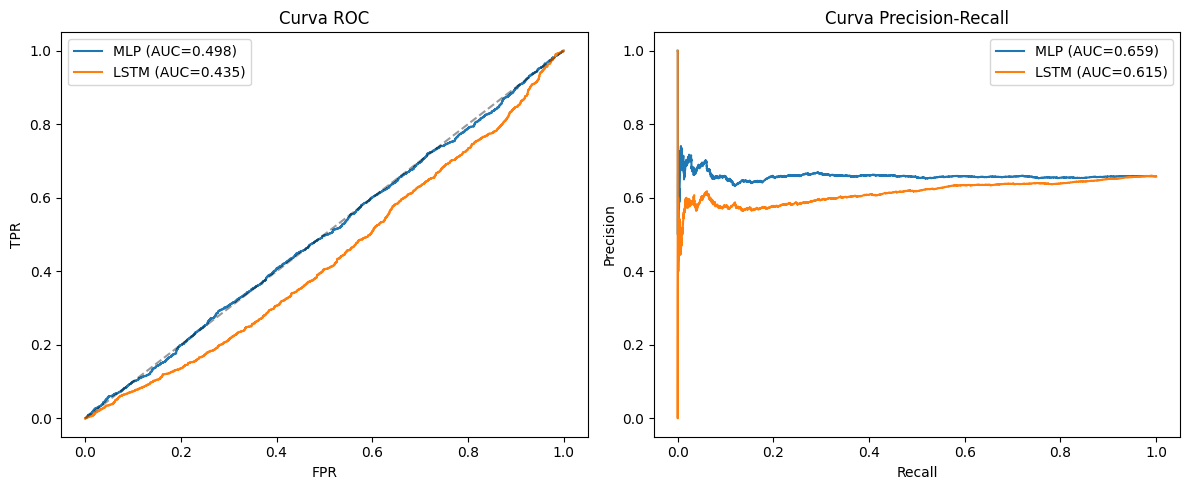

In [23]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# ROC
plt.subplot(1,2,1)
plt.plot(res_mlp['fpr'], res_mlp['tpr'], label=f"MLP (AUC={res_mlp['roc_auc']:.3f})")
plt.plot(res_lstm['fpr'], res_lstm['tpr'], label=f"LSTM (AUC={res_lstm['roc_auc']:.3f})")
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()

# PR
plt.subplot(1,2,2)
plt.plot(res_mlp['recall_curve'], res_mlp['precision_curve'], label=f"MLP (AUC={res_mlp['pr_auc']:.3f})")
plt.plot(res_lstm['recall_curve'], res_lstm['precision_curve'], label=f"LSTM (AUC={res_lstm['pr_auc']:.3f})")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()

plt.tight_layout()
plt.show()


## 10. Discussão

- O **LSTM** tende a performar melhor em dados sequenciais por capturar dependências temporais na janela.
- O **MLP** é um baseline importante: aprende padrões agregados, mas não modela explicitamente a ordem temporal.
- Em problemas raros, **PR-AUC** e **Recall** são métricas mais informativas do que apenas acurácia.

**Interpretação operacional:** um modelo com maior *Recall* reduz o risco de deixar incidentes passarem despercebidos, mas pode aumentar falsos positivos — trade-off típico em AIOps.



## 11. Conformidade Regulatória

O uso de dados sintéticos neste projeto garante aderência à **LGPD** e à **Resolução BCB nº 304/2023**, que exigem proteção de dados pessoais e resiliência operacional. Em ambientes reais, seria necessário aplicar anonimização, governança de dados e auditoria contínua. Este experimento demonstra que é possível aplicar IA sem comprometer informações sensíveis, mantendo alinhamento regulatório.


## 12. Limitações e melhorias

**Limitações:**
- Dataset sintético pode não representar toda a complexidade e ruídos de produção.
- Rotulagem por heurística (risk score) é simplificada.

**Melhorias possíveis:**
- Incorporar múltiplos serviços (multivariado por serviço) e sazonalidade/choques.
- Testar **Transformers para séries temporais** (encoder) e comparar com LSTM.
- Explorar **CNN (Convolutional Neural Networks)** aplicadas a séries temporais, para extrair padrões locais e detectar anomalias em métricas de observabilidade.
- Ajustar *threshold* de decisão por custo (FN vs FP) e calibrar probabilidades.
- Incluir logs (módulo complementar) para enriquecer a triagem de incidentes.
- **Escalar o volume de dados sintéticos**: neste projeto usamos 4.000 a 30.000 registros por simplicidade acadêmica, mas em ambientes bancários reais seriam necessários **centenas de milhares ou milhões de registros**, exigindo pipelines distribuídos e GPUs para treinamento eficiente.


## 13. Conclusão Aplicada ao Setor Bancário

Este estudo mostra que **redes neurais artificiais** podem ser integradas a pipelines de observabilidade em bancos para antecipar falhas e incidentes, fortalecendo a resiliência operacional exigida por normas regulatórias. A comparação entre MLP e LSTM evidencia que modelos sequenciais capturam melhor dependências temporais, enquanto o MLP serve como baseline confiável. Em ambientes bancários críticos, é preferível gerar alguns alertas falsos do que deixar passar um incidente que comprometa serviços essenciais como autenticação ou processamento de transações.

Embora o dataset utilizado neste projeto seja reduzido (4.000 a 30.000 registros) para fins acadêmicos, em bancos grandes, seria necessário trabalhar com **milhões de métricas reais por dia**, integrando arquiteturas mais robustas como CNNs e Transformers. Isso demonstra que a abordagem aqui apresentada é escalável e pode evoluir para atender às demandas de ambientes financeiros de grande porte.

